In [69]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt

from lmfit import models

In [70]:
# nozzle sizes in mu m
noz_ID = [32,32,32,64,64,64]

# measured D[4][3]
mean_diam = [179.76864624, 184.3699646, 177.406326294, 246.732009888, 254.487854004, 491.828399658]


In [71]:
# Guess for error in nozzle ID
err_noz_ID = [1]*6

# measured error in D[4][3]
err_mean_diam = [19.3167552948, 17.9351501465, 19.3943424225, 31.3087768555, 34.9372062683, 83.3335037231]

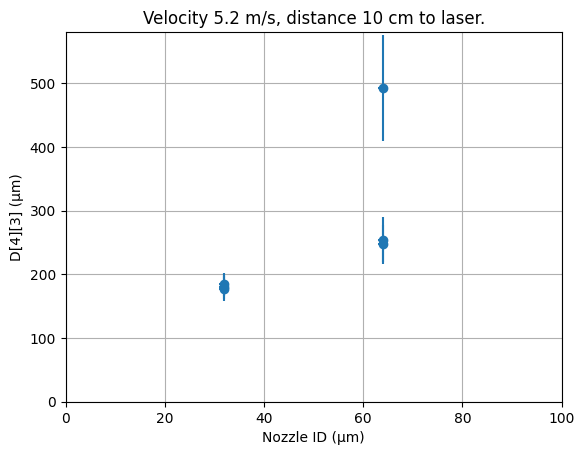

In [72]:
plt.figure()

plt.errorbar(noz_ID, mean_diam, xerr=err_noz_ID, yerr=err_mean_diam, fmt='o')

plt.title(r"Velocity 5.2 m/s, distance 10 cm to laser.")
plt.xlabel(r"Nozzle ID (μm)")
plt.ylabel(r"D[4][3] (μm)")

plt.xlim(0, 100)
plt.ylim(0, 580)

plt.grid(True)

## Normalized data

In [73]:
# devide the average by by the nozzle ID and you'll get a normalized ratio

mean_diam_norm = [5.617770195, 5.761561394, 5.543947697, 3.855187655, 3.976372719, 7.684818745]

In [74]:

# normalized error
err_mean_diam_norm = [0.603648603, 0.560473442, 0.606073201, 0.489199638, 0.545893848, 1.302086]

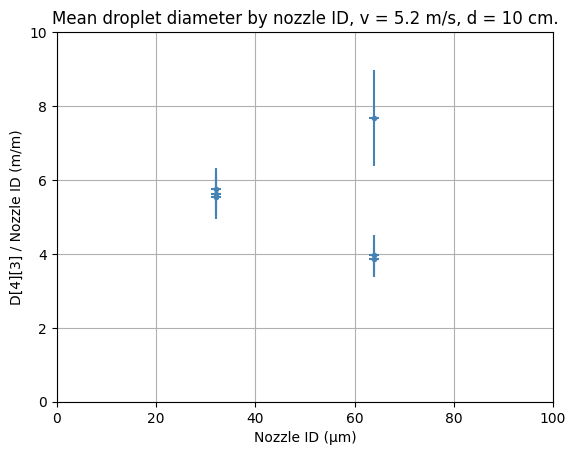

In [75]:
plt.figure()

plt.errorbar(noz_ID, mean_diam_norm, xerr=err_noz_ID, yerr=err_mean_diam_norm, fmt='.', color="steelblue")

plt.title(r"Mean droplet diameter by nozzle ID, v = 5.2 m/s, d = 10 cm.")
plt.xlabel(r"Nozzle ID (μm)")
plt.ylabel(r"D[4][3] / Nozzle ID (m/m)")

plt.xlim(0, 100)
plt.ylim(0, 10)

plt.grid(True)

## fit

In [80]:
def fit_function(x_fit, p1, p2,p3):
    mean_diam_fit = p1 * x_fit + p2  
    return mean_diam_fit

In [81]:
fit_model = models.Model(fit_function)

err_mean_diam_norm_array = np.array(err_mean_diam_norm)
err_mean_diam_norm_inv = 1 / err_mean_diam_norm_array

fit_result = fit_model.fit(mean_diam_norm, x_fit=np.array(noz_ID), weights=err_mean_diam_norm_inv, p1=1, p2=1)

C:\Users\tryst\AppData\Local\Temp\ipykernel_4832\2799584812.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  plt.plot(noz_ID, fit_result.best_fit, 'r-', color="red")


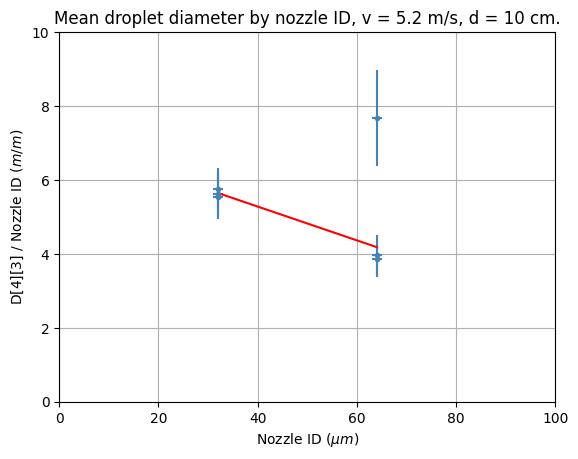

In [82]:
plt.figure()

plt.errorbar(noz_ID, mean_diam_norm, xerr=err_noz_ID, yerr=err_mean_diam_norm, fmt='.', color="steelblue")
plt.plot(noz_ID, fit_result.best_fit, 'r-', color="red")

plt.title(r"Mean droplet diameter by nozzle ID, v = 5.2 m/s, d = 10 cm.")
plt.xlabel(r"Nozzle ID ($\mu m$)")
plt.ylabel(r"D[4][3] / Nozzle ID ($m/m$)")

plt.xlim(0, 100)
plt.ylim(0, 10)

plt.grid(True)

In [ ]:
print(fit_result.fit_report())

[[Model]]
    Model(fit_function)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 7
    # data points      = 6
    # variables        = 2
    chi-square         = 7.89816302
    reduced chi-square = 1.97454075
    Akaike info crit   = 5.64922440
    Bayesian info crit = 5.23274334
    R-squared          = -0.26481178
[[Variables]]
    p1: -0.04575542 +/- 0.02145389 (46.89%) (init = 1)
    p2:  7.11162787 +/- 1.07523100 (15.12%) (init = 1)
[[Correlations]] (unreported correlations are < 0.100)
    C(p1, p2) = -0.9477
